In [1]:
!ls "../datos_cultivos/"

 CHLORELLA-20260126T182532Z-3-001
 Chlorella-20260126T182158Z-3-001
 Haematococcus_verde1-20260126T202441Z-3-001
 Haematococcus_verde2-20260126T213243Z-3-001
'Scenedesmus acutus_ 1_50-20260126T214011Z-3-001'
'Scenedesmus acutus_1_100-20260126T214147Z-3-001'


# Image reading

In [2]:
from pathlib import Path

In [3]:
TYPES = ["amp", "flr_1", "flr_2", "flr_3", "flu", "mask", "phase"]

def group7(paths):
    groups = {} # key -> common_img_id, value -> another dictionary with img types, {amp: amp_img, flr_1: flr_1_img, ...}

    for path in paths:
        stem = path.stem  # name without .png
        t = next((t for t in TYPES if stem.endswith("_" + t)), None)
        if t is None:
            continue
        base = stem[:-(len(t) + 1)]  # remove "_type"
        groups.setdefault(base, {})[t] = path # add image to dictionary (or create it if it doesn't already)

    # Return only coplete microalgaes (7/7)
    resultado = []
    for d in groups.values():
        if all(t in d for t in TYPES):
            resultado.append([d[t] for t in TYPES])

    return resultado

def load_dataset(base_dir):
    '''
    class_prefix = {"CH" : 0, # Chlorella
                    "HA" : 1, # Haematococcus
                    "SC" : 2} # Scenedesmus
    '''
    class_prefix = {"CH" : 0, # Chlorella
                    "HA" : 1 # Haematococcus
                   }

    # lista de listas, una por clase
    imgs = [[] for _ in range(len(class_prefix))]

    # Iterate for each class
    for class_dir in base_dir.iterdir():
        if not class_dir.is_dir():
            continue

        # Only read imgs in folders with prefix of microalgae that we want (Chlorella -> CH, Haematococcus -> HA, ...)
        for prefix, idx in class_prefix.items():
            if class_dir.name.upper().startswith(prefix):
                # Only read imgs under folder named class...
                paths = [p for p in class_dir.rglob("class*/*.png")]
                imgs[idx].extend(group7(paths))

    return imgs

In [4]:
BASE_DIR = Path("..") / "datos_cultivos"
class_names = ["Chlorella", "Haematococcus"]
imgs = load_dataset(BASE_DIR)

# Preprocess

In [57]:
# What we have now:
# imgs[0] -> images in first class
# imgs[1] -> images in second class
# ...
# imgs[i] -> images in class i
# --
# imgs[i][j] -> 7-tuple of images of class i, microalgae j
# each microalgae has 7 images ("amp", "flr_1", "flr_2", "flr_3", "flu", "mask", "phase")
# imgs[i][j][0] -> image "amp" of microalgae j in class i
# Use same number of images per class
imgs_per_class = min([len(i) for i in imgs])
imgs[0] = imgs[0][:imgs_per_class]
imgs[1] = imgs[1][:imgs_per_class]

print("Number of classes: ", len(imgs))

for i in range(len(imgs)):
    print("Images per class ", i, ": ", len(imgs[i]))

Number of classes:  2
Images per class  0 :  1727
Images per class  1 :  1727


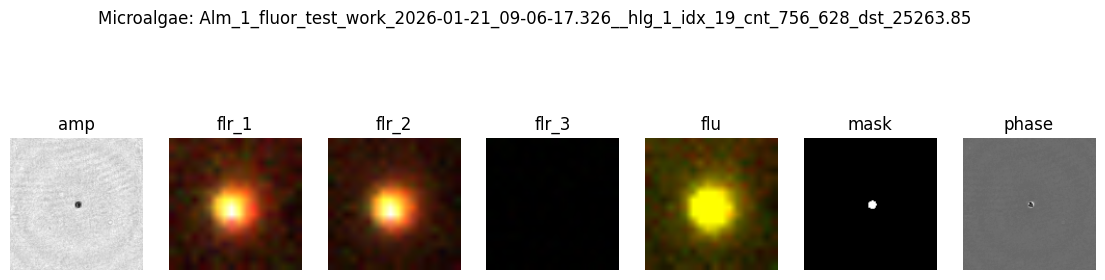

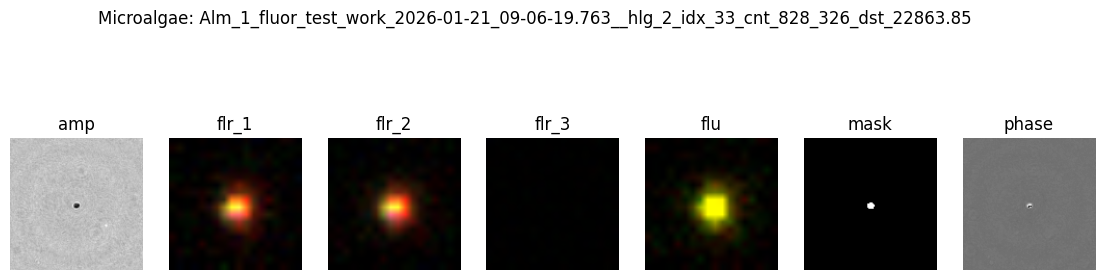

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

def show_microalgae_imgs(path):

    plt.figure(figsize=(14, 4))

    for i, (p, t) in enumerate(zip(path, TYPES)):
        img = Image.open(p)
        plt.subplot(1, 7, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(t)
        plt.axis("off")

    plt.suptitle("Microalgae: " + p.name[:-len("_phase.png")])
    plt.show()

show_microalgae_imgs(imgs[0][0]) # 7-tuple of Microalgae 0
show_microalgae_imgs(imgs[0][1]) # 7-tuple of Microalgae 1

In [7]:
# Right now, imgs[0] has the imgs of the first class, imgs[1] the images of the second class, and so on
# Our model wants two 1D vectors of same length, such as img1-label1, img2-label2, ... 
X, Y = [], []

for y, microalgae in enumerate(imgs):
    X.extend(microalgae)
    Y.extend([y] * len(microalgae))

len(X), len(Y), Y[:5], Y[-5:]

(3454, 3454, [0, 0, 0, 0, 0], [1, 1, 1, 1, 1])

# Keras

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.array(X, dtype=object)   # shape (N,)
Y = np.array(Y, dtype=np.int32) # shape (N,)

# Split train vs temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y,
    test_size=0.30,          # 30% para val+test
    random_state=42,
    stratify=Y
)

# Split temp en validation y test (15% + 15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,          # mitad y mitad
    random_state=42,
    stratify=y_temp
)

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Shapes:
Train: (2417, 7) (2417,)
Val:   (518, 7) (518,)
Test:  (519, 7) (519,)


In [9]:
import tensorflow as tf

IMG_SIZE = 128
BATCH = 32

# Reads one microalgae from disk (7 images)
# Decode them
# Resize to IMG_SIZExIMG_SIZE
# Normalize to [0,1]
# Concatenate the 7 images as different channels from a single 7D image
def load_7png(paths7, label):
    # paths7: tensor shape (7,) con strings
    imgs = []
    for i in range(7):
        img_bytes = tf.io.read_file(paths7[i])
        img = tf.image.decode_png(img_bytes, channels=1)              # [H,W,1]
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32) / 255.0
        imgs.append(img)

    x = tf.concat(imgs, axis=-1)  # [H,W,7]
    return x, label

def make_dataset(X, Y, training):
    # X are paths, turn them into strings
    X = np.array([[str(p) for p in sample7] for sample7 in X], dtype=np.string_)
    Y = np.array(Y, dtype=np.int32)

    # Now we create a dataset like (X[0], Y[0]), (X[1], Y[1]), ...
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if training:
        ds = ds.shuffle(min(len(X), 2000), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(load_7png, num_parallel_calls=tf.data.AUTOTUNE) # Convert from string to tensor image
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val, y_val, training=False)


In [10]:
from tensorflow import keras
from tensorflow.keras import layers

def make_model():
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 7))

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    out = layers.Dense(len(imgs), activation="softmax")(x)
    model = keras.Model(inp, out)
    return model

model = make_model()
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 7)]     0         
                                                                 
 conv2d (Conv2D)             (None, 128, 128, 16)      1024      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 64)        18496 

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, min_delta=1e-3, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        "best_model.keras", monitor="val_loss", save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6
    ),
]


In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=callbacks
)

Epoch 1/200
76/76 [==============================] - 12s 96ms/step - loss: 0.5859 - accuracy: 0.6885 - val_loss: 0.5531 - val_accuracy: 0.7085 - lr: 0.0010
Epoch 2/200
76/76 [==============================] - 7s 93ms/step - loss: 0.5007 - accuracy: 0.7708 - val_loss: 0.4221 - val_accuracy: 0.8069 - lr: 0.0010
Epoch 3/200
76/76 [==============================] - 7s 94ms/step - loss: 0.4037 - accuracy: 0.8250 - val_loss: 0.3876 - val_accuracy: 0.8282 - lr: 0.0010
Epoch 4/200
76/76 [==============================] - 7s 94ms/step - loss: 0.3973 - accuracy: 0.8254 - val_loss: 0.3701 - val_accuracy: 0.8340 - lr: 0.0010
Epoch 5/200
76/76 [==============================] - 7s 97ms/step - loss: 0.3890 - accuracy: 0.8237 - val_loss: 0.4241 - val_accuracy: 0.8108 - lr: 0.0010
Epoch 6/200
76/76 [==============================] - 7s 94ms/step - loss: 0.3799 - accuracy: 0.8333 - val_loss: 0.3716 - val_accuracy: 0.8456 - lr: 0.0010
Epoch 7/200
76/76 [==============================] - 7s 93ms/step - l

# Load best model

In [13]:
from tensorflow import keras

model = keras.models.load_model("best_model.keras")

embedding_model = keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output  # GlobalAveragePooling
)

## Test

In [14]:
import tensorflow as tf
import numpy as np

IMG_SIZE = (128, 128)

def read_gray_resize(p):
    img = tf.io.read_file(p)
    # Si algunas son PNG, esto también funciona si usas decode_image:
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img  # (128,128,1)

def load_7ch(paths7):
    # paths7: tf.Tensor shape (7,)
    imgs = [read_gray_resize(paths7[i]) for i in range(7)]
    x = tf.concat(imgs, axis=-1)   # (128,128,7)
    return x

# Asegura que esto sea un array (N,7) de strings
X_test_7 = np.stack([np.array(x, dtype=str) for x in X_test], axis=0)

ds_test = tf.data.Dataset.from_tensor_slices(X_test_7)
ds_test = ds_test.map(load_7ch, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(32).prefetch(tf.data.AUTOTUNE)

y_prob = model.predict(ds_test)
y_pred = y_prob.argmax(axis=1)


17/17 [==============================] - 2s 91ms/step


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Test accuracy: 0.9171483622350675

Classification report:
              precision    recall  f1-score   support

           0     0.9255    0.9077    0.9165       260
           1     0.9091    0.9266    0.9178       259

    accuracy                         0.9171       519
   macro avg     0.9173    0.9172    0.9171       519
weighted avg     0.9173    0.9171    0.9171       519


Confusion matrix:
[[236  24]
 [ 19 240]]


In [16]:
conf = y_prob.max(axis=1)

wrong = y_pred != y_test

print("Conf media correctos:", conf[~wrong].mean())
print("Conf media errores:  ", conf[wrong].mean())


Conf media correctos: 0.9239728
Conf media errores:   0.7672733


In [17]:
# Construye X_val_7 igual que hiciste con test
X_val_7 = np.stack([np.array(x, dtype=str) for x in X_val], axis=0)

ds_val = tf.data.Dataset.from_tensor_slices(X_val_7)
ds_val = ds_val.map(load_7ch, num_parallel_calls=tf.data.AUTOTUNE)
ds_val = ds_val.batch(32).prefetch(tf.data.AUTOTUNE)

# Predicciones en validation
y_prob_val = model.predict(ds_val)
y_pred_val = y_prob_val.argmax(axis=1)


17/17 [==============================] - 1s 70ms/step


In [18]:
taus = np.linspace(0.6, 0.95, 20)

for tau in taus:
    pred_tau = np.where(y_prob_val.max(axis=1) < tau, -1, y_pred_val)
    
    known = y_val != -1
    acc_known = accuracy_score(y_val[known], pred_tau[known])
    reject_rate = np.mean(pred_tau == -1)
    
    print(f"tau={tau:.2f} | acc_known={acc_known:.3f} | reject={reject_rate:.2%}")


tau=0.60 | acc_known=0.919 | reject=2.51%
tau=0.62 | acc_known=0.913 | reject=3.28%
tau=0.64 | acc_known=0.913 | reject=3.47%
tau=0.66 | acc_known=0.903 | reject=4.83%
tau=0.67 | acc_known=0.900 | reject=5.41%
tau=0.69 | acc_known=0.890 | reject=6.95%
tau=0.71 | acc_known=0.882 | reject=7.92%
tau=0.73 | acc_known=0.875 | reject=8.69%
tau=0.75 | acc_known=0.865 | reject=9.65%
tau=0.77 | acc_known=0.861 | reject=10.42%
tau=0.78 | acc_known=0.842 | reject=12.36%
tau=0.80 | acc_known=0.838 | reject=12.93%
tau=0.82 | acc_known=0.828 | reject=14.09%
tau=0.84 | acc_known=0.811 | reject=15.83%
tau=0.86 | acc_known=0.790 | reject=18.15%
tau=0.88 | acc_known=0.761 | reject=21.62%
tau=0.89 | acc_known=0.739 | reject=24.13%
tau=0.91 | acc_known=0.707 | reject=27.80%
tau=0.93 | acc_known=0.647 | reject=33.98%
tau=0.95 | acc_known=0.579 | reject=41.51%


In [19]:
tau = 0.73

pred_tau_test = np.where(
    y_prob.max(axis=1) < tau,
    -1,
    y_pred
)

known_mask = pred_tau_test != -1

acc_known_test = accuracy_score(
    y_test[known_mask],
    pred_tau_test[known_mask]
)

reject_rate_test = np.mean(pred_tau_test == -1)

print("TEST acc (known):", acc_known_test)
print("TEST reject rate:", reject_rate_test)


TEST acc (known): 0.9516806722689075
TEST reject rate: 0.08285163776493257


In [30]:
from pathlib import Path
import numpy as np
import tensorflow as tf

CLASS_NAMES = ["Chlorella", "Haematococcus"]
IMG_SIZE = (128, 128)

# ---------- Carga 1 imagen (grayscale) -> (128,128,1) float32 ----------
def _read_gray_resize(path):
    # Acepta Path, str o tf.Tensor
    if isinstance(path, Path):
        path = str(path)

    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img  # (128,128,1)

# ---------- Construye X (1,128,128,7) a partir de 7 paths ----------
def load_single_microalga(paths7):
    # paths7: iterable de 7 Paths
    imgs = [_read_gray_resize(p) for p in paths7]
    x = tf.concat(imgs, axis=-1)          # (128,128,7)
    x = tf.expand_dims(x, axis=0)         # (1,128,128,7)
    return x

# ---------- Construye las 7 rutas a partir del base_id ----------
def build_paths7_from_base(folder, base_id):
    folder = Path(folder)

    # Busca archivos que contengan el base_id dentro del nombre
    # (ajusta patrón si tus nombres tienen un formato más estricto)
    hits = sorted(folder.glob(f"*{base_id}*"))

    if len(hits) < 7:
        raise FileNotFoundError(
            f"Encontré {len(hits)} archivos que contienen base_id='{base_id}' en {folder}.\n"
            f"Necesito 7. Ejemplos:\n" + "\n".join(str(p.name) for p in hits[:10])
        )

    # Si hay más de 7 (por thumbnails, duplicados, etc.), aquí decides qué 7 son “las buenas”.
    # Por defecto: coge las primeras 7 en orden alfabético.
    paths7 = hits[:7]

    return paths7

# ---------- Predicción completa ----------
def predict_microalga_from_folder_baseid(model, embedding_model, centroids, tau, folder, base_id):
    paths7 = build_paths7_from_base(folder, base_id)
    x = load_single_microalga(paths7)

    probs = model.predict(x, verbose=0)[0]
    pred_soft = int(np.argmax(probs))

    emb = embedding_model.predict(x, verbose=0)[0]  # (D,)

    C, c_keys = _centroids_to_array(centroids)      # (K,D) + nombres
    dists = np.linalg.norm(emb[None, :] - C, axis=1)
    dmin = float(dists.min())
    argmin = int(dists.argmin())

    label = "Unknown" if dmin > tau else CLASS_NAMES[pred_soft]

    return {
        "pred": label,
        "softmax_class": CLASS_NAMES[pred_soft],
        "softmax_probs": probs.astype(float),
        "dmin": dmin,
        "distances_to_centroids": {c_keys[i]: float(dists[i]) for i in range(len(dists))},
        "nearest_centroid": c_keys[argmin],
        "tau": float(tau),
        "folder": str(folder),
        "base_id": base_id,
        "paths7": [str(p) for p in paths7],
    }


def _centroids_to_array(centroids):
    # Caso 1: ya es array/lista de arrays
    if isinstance(centroids, (list, tuple, np.ndarray)):
        c = np.asarray(centroids, dtype=np.float32)
        if c.ndim != 2:
            raise ValueError(f"Centroids debe ser 2D (K,D). Got shape={c.shape}")
        return c, [f"c{i}" for i in range(c.shape[0])]

    # Caso 2: dict {"c0": vec, "c1": vec} o {"Chlorella": vec, ...}
    if isinstance(centroids, dict):
        keys = sorted(centroids.keys())
        c = np.stack([np.asarray(centroids[k], dtype=np.float32) for k in keys], axis=0)
        return c, keys

    raise TypeError(f"Tipo centroids no soportado: {type(centroids)}")

# Calculate centroids

In [31]:
# Construye X_train_7
X_train_7 = np.stack([np.array(x, dtype=str) for x in X_train], axis=0)

ds_train_embed = tf.data.Dataset.from_tensor_slices(X_train_7)
ds_train_embed = ds_train_embed.map(load_7ch, num_parallel_calls=tf.data.AUTOTUNE)
ds_train_embed = ds_train_embed.batch(32).prefetch(tf.data.AUTOTUNE)
embs_train = embedding_model.predict(ds_train_embed, verbose=0)
print(embs_train.shape)   # (N_train, D)
import numpy as np

CLASS_NAMES = ["Chlorella", "Haematococcus"]

centroids = {}

for k, name in enumerate(CLASS_NAMES):
    embs_k = embs_train[y_train == k]
    centroids[name] = embs_k.mean(axis=0)

# Comprobación
for k, v in centroids.items():
    print(k, v.shape)


(2417, 64)
Chlorella (64,)
Haematococcus (64,)


In [32]:
import numpy as np
import tensorflow as tf

CLASS_NAMES = ["Chlorella", "Haematococcus"]

def predict_one_with_tau(model, embedding_model, centroids, tau, paths7):
    """
    paths7: lista/tupla de 7 rutas (str o Path) en el orden TYPES
    devuelve dict con pred final + info
    """
    # --- construir x (1,128,128,7) ---
    x = load_single_microalga(paths7)  # usa tu función (ya devuelve batch=1)

    # --- softmax ---
    probs = model.predict(x, verbose=0)[0]
    pred_soft = int(np.argmax(probs))
    conf = float(np.max(probs))

    # --- embedding ---
    emb = embedding_model.predict(x, verbose=0)[0]  # (D,)

    # --- distancias a centroides ---
    C, c_keys = _centroids_to_array(centroids)      # (K,D)
    dists = np.linalg.norm(emb[None, :] - C, axis=1)
    dmin = float(dists.min())
    nearest = c_keys[int(dists.argmin())]

    # --- regla de rechazo ---
    if dmin > tau:
        pred_final = "Unknown"
    else:
        pred_final = CLASS_NAMES[pred_soft]

    return {
        "pred": pred_final,
        "softmax_class": CLASS_NAMES[pred_soft],
        "softmax_conf": conf,
        "softmax_probs": probs.astype(float),
        "dmin": dmin,
        "nearest_centroid": nearest,
        "distances_to_centroids": {c_keys[i]: float(dists[i]) for i in range(len(dists))},
        "tau": float(tau),
        "paths7": [str(p) for p in paths7],
    }


# Calculate dmin

In [33]:
# --- embeddings de validation ---
embs_val = embedding_model.predict(ds_val, verbose=0)

# --- distancias a centroides ---
C, c_keys = _centroids_to_array(centroids)   # (K,D)
dists_val = np.linalg.norm(
    embs_val[:, None, :] - C[None, :, :],
    axis=2
)                                            # (N,K)

dmin_val = dists_val.min(axis=1)              # (N,)


In [34]:
print("dmin val: min / mean / max =",
      dmin_val.min(), dmin_val.mean(), dmin_val.max())

dmin val: min / mean / max = 0.11511887 1.054699 4.3317204


In [35]:
y_prob_val = model.predict(ds_val, verbose=0)
y_pred_val = y_prob_val.argmax(axis=1)

In [36]:
from sklearn.metrics import accuracy_score
import numpy as np

taus_dist = np.linspace(
    dmin_val.min(),
    dmin_val.max(),
    30
)

for tau_dist in taus_dist:
    pred_final = np.where(dmin_val > tau_dist, -1, y_pred_val)

    mask = pred_final != -1
    acc_known = accuracy_score(
        y_val[mask],
        pred_final[mask]
    ) if mask.any() else np.nan

    reject = np.mean(pred_final == -1)

    print(
        f"tau_dist={tau_dist:.3f} | "
        f"acc_known={acc_known:.3f} | "
        f"reject={reject:.2%}"
    )


tau_dist=0.115 | acc_known=1.000 | reject=99.81%
tau_dist=0.261 | acc_known=0.929 | reject=94.59%
tau_dist=0.406 | acc_known=0.939 | reject=84.17%
tau_dist=0.551 | acc_known=0.953 | reject=71.04%
tau_dist=0.697 | acc_known=0.936 | reject=60.81%
tau_dist=0.842 | acc_known=0.937 | reject=54.25%
tau_dist=0.988 | acc_known=0.929 | reject=45.75%
tau_dist=1.133 | acc_known=0.924 | reject=39.00%
tau_dist=1.278 | acc_known=0.926 | reject=32.63%
tau_dist=1.424 | acc_known=0.925 | reject=25.29%
tau_dist=1.569 | acc_known=0.929 | reject=18.92%
tau_dist=1.715 | acc_known=0.929 | reject=10.62%
tau_dist=1.860 | acc_known=0.930 | reject=9.46%
tau_dist=2.005 | acc_known=0.930 | reject=8.88%
tau_dist=2.151 | acc_known=0.931 | reject=7.53%
tau_dist=2.296 | acc_known=0.932 | reject=6.76%
tau_dist=2.442 | acc_known=0.930 | reject=5.60%
tau_dist=2.587 | acc_known=0.931 | reject=5.21%
tau_dist=2.732 | acc_known=0.931 | reject=4.25%
tau_dist=2.878 | acc_known=0.932 | reject=3.28%
tau_dist=3.023 | acc_known=0

In [37]:
tau_dist=1.550

In [38]:
def predict_microalga_from_folder_baseid_double_tau(
    model,
    embedding_model,
    centroids,
    tau_soft,
    tau_dist,
    folder,
    base_id,
    class_names=CLASS_NAMES
):
    paths7 = build_paths7_from_base(folder, base_id)
    x = load_single_microalga(paths7)

    # --- Softmax ---
    probs = model.predict(x, verbose=0)[0]
    pred_soft = int(np.argmax(probs))
    conf = float(np.max(probs))

    # --- Embedding + distancia a centroides ---
    emb = embedding_model.predict(x, verbose=0)[0]  # (D,)
    C, c_keys = _centroids_to_array(centroids)      # (K,D) + nombres
    dists = np.linalg.norm(emb[None, :] - C, axis=1)
    dmin = float(dists.min())
    argmin = int(dists.argmin())

    # --- Doble puerta (rechazo) ---
    accept = (conf >= tau_soft) and (dmin <= tau_dist)
    label = class_names[pred_soft] if accept else "Unknown"

    return {
        "pred": label,
        "accept": bool(accept),
        "softmax_class": class_names[pred_soft],
        "softmax_conf": conf,
        "softmax_probs": probs.astype(float),
        "dmin": dmin,
        "distances_to_centroids": {c_keys[i]: float(dists[i]) for i in range(len(dists))},
        "nearest_centroid": c_keys[argmin],
        "tau_soft": float(tau_soft),
        "tau_dist": float(tau_dist),
        "folder": str(folder),
        "base_id": base_id,
        "paths7": [str(p) for p in paths7],
    }


In [39]:
out = predict_microalga_from_folder_baseid_double_tau(
    model=model,
    embedding_model=embedding_model,
    centroids=centroids,
    tau_soft=0.73,
    tau_dist=1.55,
    folder="../datos_cultivos/Chlorella-20260126T182158Z-3-001/Chlorella/class_chlorella/",
    base_id="Alm_1_fluor_test_work_2026-01-21_09-06-39.32__hlg_9_idx_34_cnt_1806_814_dst_24231.93",
)

out


{'pred': 'Chlorella',
 'accept': True,
 'softmax_class': 'Chlorella',
 'softmax_conf': 0.9812893271446228,
 'softmax_probs': array([0.98128933, 0.01871067]),
 'dmin': 0.5002776384353638,
 'distances_to_centroids': {'Chlorella': 0.5002776384353638,
  'Haematococcus': 2.8771932125091553},
 'nearest_centroid': 'Chlorella',
 'tau_soft': 0.73,
 'tau_dist': 1.55,
 'folder': '../datos_cultivos/Chlorella-20260126T182158Z-3-001/Chlorella/class_chlorella/',
 'base_id': 'Alm_1_fluor_test_work_2026-01-21_09-06-39.32__hlg_9_idx_34_cnt_1806_814_dst_24231.93',
 'paths7': ['../datos_cultivos/Chlorella-20260126T182158Z-3-001/Chlorella/class_chlorella/Alm_1_fluor_test_work_2026-01-21_09-06-39.32__hlg_9_idx_34_cnt_1806_814_dst_24231.93_amp.png',
  '../datos_cultivos/Chlorella-20260126T182158Z-3-001/Chlorella/class_chlorella/Alm_1_fluor_test_work_2026-01-21_09-06-39.32__hlg_9_idx_34_cnt_1806_814_dst_24231.93_flr_1.png',
  '../datos_cultivos/Chlorella-20260126T182158Z-3-001/Chlorella/class_chlorella/Alm_1_

# See model performance in test & new data (Scenedesmus)

In [40]:
import numpy as np

def predict_test_double_tau(
    model,
    embedding_model,
    ds_test,
    centroids,
    tau_soft,
    tau_dist
):
    # --- Softmax ---
    probs = model.predict(ds_test, verbose=0)          # (N,2)
    pred_soft = probs.argmax(axis=1)                   # (N,)
    conf = probs.max(axis=1)                           # (N,)

    # --- Embeddings + distancias ---
    embs = embedding_model.predict(ds_test, verbose=0) # (N,D)
    C, c_keys = _centroids_to_array(centroids)         # (K,D)
    dists = np.linalg.norm(
        embs[:, None, :] - C[None, :, :],
        axis=2
    )                                                   # (N,K)
    dmin = dists.min(axis=1)                            # (N,)

    # --- Doble puerta ---
    accept = (conf >= tau_soft) & (dmin <= tau_dist)
    pred_final = np.where(accept, pred_soft, -1)       # -1 = Unknown

    return {
        "pred_final": pred_final,
        "pred_soft": pred_soft,
        "conf": conf,
        "dmin": dmin,
        "probs": probs,
        "accept": accept
    }


In [41]:
tau_soft = 0.73
tau_dist = 1.55

out_test = predict_test_double_tau(
    model,
    embedding_model,
    ds_test,
    centroids,
    tau_soft,
    tau_dist
)


In [42]:
from sklearn.metrics import accuracy_score

mask = out_test["pred_final"] != -1

acc_known = accuracy_score(
    y_test[mask],
    out_test["pred_final"][mask]
)

reject_rate = np.mean(~mask)

print("TEST acc (accepted):", acc_known)
print("TEST reject rate:", reject_rate)

TEST acc (accepted): 0.9472295514511874
TEST reject rate: 0.2697495183044316


In [43]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(
    y_test[mask],
    out_test["pred_final"][mask]
))

print(classification_report(
    y_test[mask],
    out_test["pred_final"][mask],
    target_names=CLASS_NAMES,
    digits=4
))

[[218   9]
 [ 11 141]]
               precision    recall  f1-score   support

    Chlorella     0.9520    0.9604    0.9561       227
Haematococcus     0.9400    0.9276    0.9338       152

     accuracy                         0.9472       379
    macro avg     0.9460    0.9440    0.9450       379
 weighted avg     0.9472    0.9472    0.9472       379



In [45]:
# Mirar los ejemplos que se han rechazado
idx_rejected = np.where(out_test["pred_final"] == -1)[0]

print("Número de rechazados:", len(idx_rejected))
print("Ejemplo rechazado:", idx_rejected[:5])

i = idx_rejected[0]
print("True label:", CLASS_NAMES[y_test[i]])
print("softmax probs:", out_test["probs"][i])
print("conf:", out_test["conf"][i])
print("dmin:", out_test["dmin"][i])

Número de rechazados: 140
Ejemplo rechazado: [ 1  4  8 13 15]
True label: Haematococcus
softmax probs: [0.01603121 0.98396873]
conf: 0.98396873
dmin: 2.0644238


# Test Scenedesmus

In [46]:
from pathlib import Path

def load_dataset_3classes(base_dir):
    class_prefix = {"SC": 2}  # SC = Scenedesmus
    imgs = [[], [], []]

    for class_dir in base_dir.iterdir():
        if not class_dir.is_dir():
            continue

        for prefix, idx in class_prefix.items():
            if class_dir.name.upper().startswith(prefix):
                paths = [p for p in class_dir.rglob("class*/*.png")]
                imgs[idx].extend(group7(paths))

    return imgs

BASE_DIR = Path("..") / "datos_cultivos"
imgs3 = load_dataset_3classes(BASE_DIR)

print("SC:", len(imgs3[2]))


SC: 408


In [47]:
import numpy as np
import tensorflow as tf

X_sc = np.array(imgs3[2], dtype=object)  # (N_sc, 7) como objetos Path
X_sc_7 = np.stack([np.array(x, dtype=str) for x in X_sc], axis=0)  # (N_sc,7) strings

ds_sc = tf.data.Dataset.from_tensor_slices(X_sc_7)
ds_sc = ds_sc.map(load_7ch, num_parallel_calls=tf.data.AUTOTUNE)
ds_sc = ds_sc.batch(32).prefetch(tf.data.AUTOTUNE)

print("Scenedesmus samples:", len(X_sc))


Scenedesmus samples: 408


In [48]:
tau_soft = 0.73
tau_dist = 1.55

out_sc = predict_test_double_tau(
    model=model,
    embedding_model=embedding_model,
    ds_test=ds_sc,           # aquí metemos Scenedesmus
    centroids=centroids,
    tau_soft=tau_soft,
    tau_dist=tau_dist
)

reject_rate_sc = np.mean(out_sc["pred_final"] == -1)
false_accept_rate_sc = 1 - reject_rate_sc

print("SCENEDESMUS reject rate (Unknown):", reject_rate_sc)
print("SCENEDESMUS false accept rate:", false_accept_rate_sc)


SCENEDESMUS reject rate (Unknown): 0.625
SCENEDESMUS false accept rate: 0.375


# See taus

In [49]:
import numpy as np

# --- calcula dmin una sola vez ---
def dmin_from_ds(embedding_model, ds, centroids):
    embs = embedding_model.predict(ds, verbose=0)
    C, _ = _centroids_to_array(centroids)
    dists = np.linalg.norm(embs[:, None, :] - C[None, :, :], axis=2)
    return dists.min(axis=1)

dmin_test = dmin_from_ds(embedding_model, ds_test, centroids)
dmin_sc   = dmin_from_ds(embedding_model, ds_sc, centroids)

# --- también calcula conf una sola vez (por si quieres doble puerta) ---
probs_test = model.predict(ds_test, verbose=0)
conf_test = probs_test.max(axis=1)

probs_sc = model.predict(ds_sc, verbose=0)
conf_sc = probs_sc.max(axis=1)

tau_soft = 0.73  # tu actual

# rango de taus razonable (percentiles de known)
cands = np.quantile(dmin_test, [0.80, 0.85, 0.90, 0.92, 0.95, 0.97, 0.99])

print("tau_dist  | reject_known | reject_SC | false_accept_SC")
for tau_dist in cands:
    accept_known = (conf_test >= tau_soft) & (dmin_test <= tau_dist)
    accept_sc    = (conf_sc   >= tau_soft) & (dmin_sc   <= tau_dist)

    reject_known = 1 - accept_known.mean()
    reject_sc = 1 - accept_sc.mean()

    print(f"{tau_dist:7.3f} | {reject_known:10.2%} | {reject_sc:8.2%} | {1-reject_sc:14.2%}")


tau_dist  | reject_known | reject_SC | false_accept_SC
  1.512 |     27.94% |   64.22% |         35.78%
  1.602 |     22.93% |   59.07% |         40.93%
  1.713 |     17.92% |   53.43% |         46.57%
  2.045 |     15.99% |   46.32% |         53.68%
  2.569 |     12.91% |   34.56% |         65.44%
  2.797 |     11.18% |   31.86% |         68.14%
  3.397 |      9.25% |   22.79% |         77.21%


In [50]:
tau_dist = 1.55

for tau_soft in [0.70, 0.75, 0.80, 0.85, 0.90]:
    accept_known = (conf_test >= tau_soft) & (dmin_test <= tau_dist)
    accept_sc    = (conf_sc   >= tau_soft) & (dmin_sc   <= tau_dist)

    reject_known = 1 - accept_known.mean()
    reject_sc = 1 - accept_sc.mean()

    print(f"tau_soft={tau_soft:.2f} | reject_known={reject_known:.2%} | reject_SC={reject_sc:.2%}")


tau_soft=0.70 | reject_known=25.24% | reject_SC=60.29%
tau_soft=0.75 | reject_known=28.52% | reject_SC=63.24%
tau_soft=0.80 | reject_known=31.98% | reject_SC=66.42%
tau_soft=0.85 | reject_known=40.08% | reject_SC=70.10%
tau_soft=0.90 | reject_known=45.86% | reject_SC=75.74%


# Tau per class

In [51]:
import numpy as np

CLASS_NAMES = ["Chlorella", "Haematococcus"]

def predict_ds_double_tau_predclass(model, embedding_model, ds, centroids, tau_soft, tau0, tau1):
    # softmax
    probs = model.predict(ds, verbose=0)
    pred_soft = probs.argmax(axis=1)
    conf = probs.max(axis=1)

    # embeddings + distancias
    embs = embedding_model.predict(ds, verbose=0)
    C, c_keys = _centroids_to_array(centroids)

    # Alinear centroides con CLASS_NAMES (importante)
    if c_keys != CLASS_NAMES:
        idx = [c_keys.index(n) for n in CLASS_NAMES]
        C = C[idx]

    dists = np.linalg.norm(embs[:, None, :] - C[None, :, :], axis=2)  # (N,2)
    d_pred = dists[np.arange(len(pred_soft)), pred_soft]              # dist a clase predicha

    tau_by_class = np.where(pred_soft == 0, tau0, tau1)
    accept = (conf >= tau_soft) & (d_pred <= tau_by_class)

    pred_final = np.where(accept, pred_soft, -1)
    return pred_final, conf, d_pred, probs


In [52]:
# Calcula todo en VAL una vez
probs_val = model.predict(ds_val, verbose=0)
pred_val = probs_val.argmax(axis=1)
conf_val = probs_val.max(axis=1)

embs_val = embedding_model.predict(ds_val, verbose=0)
C, c_keys = _centroids_to_array(centroids)

if c_keys != CLASS_NAMES:
    idx = [c_keys.index(n) for n in CLASS_NAMES]
    C = C[idx]

dists_val = np.linalg.norm(embs_val[:, None, :] - C[None, :, :], axis=2)
d_pred_val = dists_val[np.arange(len(pred_val)), pred_val]


In [53]:
tau_soft = 0.73

cand0 = np.quantile(d_pred_val[pred_val == 0], [0.90, 0.95, 0.97, 0.99])
cand1 = np.quantile(d_pred_val[pred_val == 1], [0.90, 0.95, 0.97, 0.99])

print("Candidates CH:", cand0)
print("Candidates HA:", cand1)

best = None
best_score = -1

print("\n tau0    tau1   | reject_val")
for tau0 in cand0:
    for tau1 in cand1:
        tau_by = np.where(pred_val == 0, tau0, tau1)
        accept = (conf_val >= tau_soft) & (d_pred_val <= tau_by)
        reject_val = 1 - accept.mean()
        print(f"{tau0:6.3f}  {tau1:6.3f} | {reject_val:8.2%}")


Candidates CH: [0.94467354 1.21144633 1.31781496 1.79842362]
Candidates HA: [2.641991   3.06961193 3.28120914 3.6523592 ]

 tau0    tau1   | reject_val
 0.945   2.642 |   16.41%
 0.945   3.070 |   13.90%
 0.945   3.281 |   12.93%
 0.945   3.652 |   11.97%
 1.211   2.642 |   15.06%
 1.211   3.070 |   12.55%
 1.211   3.281 |   11.58%
 1.211   3.652 |   10.62%
 1.318   2.642 |   14.48%
 1.318   3.070 |   11.97%
 1.318   3.281 |   11.00%
 1.318   3.652 |   10.04%
 1.798   2.642 |   14.09%
 1.798   3.070 |   11.58%
 1.798   3.281 |   10.62%
 1.798   3.652 |    9.65%


In [54]:
tau0 = float(cand0[1])  # ejemplo: 95%
tau1 = float(cand1[1])

# known test
pred_test, conf_test, d_pred_test, _ = predict_ds_double_tau_predclass(
    model, embedding_model, ds_test, centroids, tau_soft, tau0, tau1
)

# Scenedesmus
pred_sc, conf_sc, d_pred_sc, _ = predict_ds_double_tau_predclass(
    model, embedding_model, ds_sc, centroids, tau_soft, tau0, tau1
)

print("KNOWN reject:", np.mean(pred_test == -1))
print("SC reject:", np.mean(pred_sc == -1))
print("SC false accept:", np.mean(pred_sc != -1))


KNOWN reject: 0.10982658959537572
SC reject: 0.29901960784313725
SC false accept: 0.7009803921568627


In [55]:
import numpy as np

# usa las variables que ya tienes:
# conf_test, dmin_test, conf_sc, dmin_sc

# define rej máximo permitido en known
max_reject_known = 0.15

# candidatos razonables
tau_soft_grid = np.linspace(0.70, 0.95, 26)   # ajusta si quieres
tau_dist_grid = np.linspace(
    np.quantile(dmin_test, 0.50),
    np.quantile(dmin_test, 0.99),
    40
)

best = None

for tau_soft in tau_soft_grid:
    for tau_dist in tau_dist_grid:
        accept_known = (conf_test >= tau_soft) & (dmin_test <= tau_dist)
        reject_known = 1 - accept_known.mean()

        if reject_known > max_reject_known:
            continue

        accept_sc = (conf_sc >= tau_soft) & (dmin_sc <= tau_dist)
        reject_sc = 1 - accept_sc.mean()

        # objetivo: maximizar reject_sc; desempate: minimizar reject_known
        score = reject_sc - 0.1 * reject_known

        if (best is None) or (score > best["score"]):
            best = {
                "tau_soft": float(tau_soft),
                "tau_dist": float(tau_dist),
                "reject_known": float(reject_known),
                "reject_sc": float(reject_sc),
                "false_accept_sc": float(1 - reject_sc),
                "score": float(score),
            }

best


{'tau_soft': 0.7,
 'tau_dist': 1.9583607322741785,
 'reject_known': 0.1464354527938343,
 'reject_sc': 0.4681372549019608,
 'false_accept_sc': 0.5318627450980392,
 'score': 0.45349370962257735}

# Softmax + Center Loss (Keras)

In [56]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = 128
EMB_DIM = 64
NUM_CLASSES = 2

def make_model_with_embedding():
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 7))

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    emb = layers.Dense(EMB_DIM, activation=None, name="emb")(x)
    emb_norm = layers.Lambda(lambda t: tf.nn.l2_normalize(t, axis=1, epsilon=1e-8),
                             name="emb_norm")(emb)

    logits = layers.Dense(NUM_CLASSES, activation="softmax", name="cls")(emb_norm)
    return keras.Model(inp, outputs=[logits, emb_norm])

# --- centers como Variable aparte (más simple/estable) ---
centers = tf.Variable(tf.zeros([NUM_CLASSES, EMB_DIM], tf.float32), trainable=False)

def center_loss_value(y_true, emb):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)         # (B,)
    c_batch = tf.gather(centers, y_true)                         # (B,D)
    diff = emb - c_batch                                         # (B,D)
    return tf.reduce_mean(tf.reduce_sum(tf.square(diff), axis=1))  # escalar

@tf.function
def update_centers(y_true, emb, alpha=0.1):
    """
    Wen et al. update:
    centers[j] -= alpha * sum(c_j - x_i) / (1 + N_j)
    """
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)  # (B,)

    c_batch = tf.gather(centers, y_true)                  # (B,D)
    diff = c_batch - emb                                  # (B,D)  <-- (c - x)

    unique, unique_idx, counts = tf.unique_with_counts(y_true)
    counts = tf.cast(counts, tf.float32)                  # (U,)

    diff_sum = tf.math.unsorted_segment_sum(diff, unique_idx, tf.shape(unique)[0])  # (U,D)
    counts = tf.reshape(counts, [-1, 1])                  # (U,1)

    delta = alpha * diff_sum / (1.0 + counts)             # (U,D)

    new_centers = tf.tensor_scatter_nd_sub(
        centers,
        tf.reshape(unique, [-1, 1]),
        delta
    )
    centers.assign(new_centers)

# --- entrenamiento ---
model2 = make_model_with_embedding()

ce = keras.losses.SparseCategoricalCrossentropy()
lambda_center = 0.01
alpha_center = 0.1

optimizer = keras.optimizers.Adam(1e-3, clipnorm=1.0)

train_acc = keras.metrics.SparseCategoricalAccuracy()
val_acc = keras.metrics.SparseCategoricalAccuracy()

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        logits, emb = model2(x, training=True)
        loss_cls = ce(y, logits)
        loss_ctr = center_loss_value(y, emb)
        loss = loss_cls + lambda_center * loss_ctr

        # debug anti-NaN (si algo explota, te lo dice aquí)
        tf.debugging.assert_all_finite(logits, "NaN/Inf in logits")
        tf.debugging.assert_all_finite(emb, "NaN/Inf in embedding")
        tf.debugging.assert_all_finite(loss, "NaN/Inf in total loss")

    grads = tape.gradient(loss, model2.trainable_variables)
    optimizer.apply_gradients(zip(grads, model2.trainable_variables))

    # update centers fuera del tape (sin afectar gradientes)
    update_centers(y, emb, alpha=alpha_center)

    train_acc.update_state(y, logits)
    return loss, loss_cls, loss_ctr

@tf.function
def val_step(x, y):
    logits, emb = model2(x, training=False)
    loss_cls = ce(y, logits)
    val_acc.update_state(y, logits)
    tf.debugging.assert_all_finite(loss_cls, "NaN/Inf in val loss")
    return loss_cls

EPOCHS = 40

for epoch in range(EPOCHS):
    train_acc.reset_state()
    val_acc.reset_state()

    # train
    for xb, yb in train_ds:
        loss, lcls, lctr = train_step(xb, yb)

    # val
    vloss = None
    for xb, yb in val_ds:
        vloss = val_step(xb, yb)

    print(f"Epoch {epoch+1:02d} | train_acc={train_acc.result():.4f} | "
          f"val_acc={val_acc.result():.4f} | last_val_loss={float(vloss):.4f}")


Epoch 01 | train_acc=0.7290 | val_acc=0.8089 | last_val_loss=0.3626
Epoch 02 | train_acc=0.8051 | val_acc=0.8166 | last_val_loss=0.2360
Epoch 03 | train_acc=0.8308 | val_acc=0.8301 | last_val_loss=0.2574
Epoch 04 | train_acc=0.8213 | val_acc=0.8514 | last_val_loss=0.3244
Epoch 05 | train_acc=0.8312 | val_acc=0.8552 | last_val_loss=0.2859
Epoch 06 | train_acc=0.8424 | val_acc=0.8668 | last_val_loss=0.3406
Epoch 07 | train_acc=0.8535 | val_acc=0.8552 | last_val_loss=0.3547


KeyboardInterrupt: 

In [ ]:
from tensorflow import keras

embedding_model2 = keras.Model(
    inputs=model2.input,
    outputs=model2.get_layer("emb_norm").output
)


# Train está shuffle, tenemos que crear otro sin alterar
# Dataset de train SIN shuffle (clave)
train_ds_noshuf = make_dataset(X_train, y_train, training=False)

# Embeddings de train
embs_train2 = embedding_model2.predict(train_ds_noshuf, verbose=0)

# Centroides
centroids2 = {}
for k, name in enumerate(CLASS_NAMES):
    centroids2[name] = embs_train2[y_train == k].mean(axis=0)

# Check rápido
for k, v in centroids2.items():
    print(k, v.shape)



In [ ]:
import numpy as np

def predict_ds_double_tau_model2(model2, embedding_model2, ds, centroids, tau_soft, tau_dist):
    # probs del modelo (salida 0)
    probs, _ = model2.predict(ds, verbose=0)
    pred_soft = probs.argmax(axis=1)
    conf = probs.max(axis=1)

    # embeddings
    embs = embedding_model2.predict(ds, verbose=0)

    # distancias a centroides
    C, c_keys = _centroids_to_array(centroids)
    if c_keys != CLASS_NAMES:
        idx = [c_keys.index(n) for n in CLASS_NAMES]
        C = C[idx]

    dists = np.linalg.norm(embs[:, None, :] - C[None, :, :], axis=2)
    dmin = dists.min(axis=1)

    # doble puerta
    accept = (conf >= tau_soft) & (dmin <= tau_dist)
    pred_final = np.where(accept, pred_soft, -1)

    return pred_final, probs, conf, dmin


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

tau_soft = 0.73

# probs/softmax en val
probs_val2, _ = model2.predict(ds_val, verbose=0)
pred_val2 = probs_val2.argmax(axis=1)
conf_val2 = probs_val2.max(axis=1)

# dmin en val
embs_val2 = embedding_model2.predict(ds_val, verbose=0)
C, c_keys = _centroids_to_array(centroids2)
if c_keys != CLASS_NAMES:
    idx = [c_keys.index(n) for n in CLASS_NAMES]
    C = C[idx]

dists_val2 = np.linalg.norm(embs_val2[:, None, :] - C[None, :, :], axis=2)
dmin_val2 = dists_val2.min(axis=1)

taus = np.linspace(np.quantile(dmin_val2, 0.50), np.quantile(dmin_val2, 0.99), 25)

best = None
print("tau_dist | acc(accepted) | reject")
for tau_dist in taus:
    accept = (conf_val2 >= tau_soft) & (dmin_val2 <= tau_dist)
    if accept.sum() == 0:
        continue
    acc = accuracy_score(y_val[accept], pred_val2[accept])
    rej = 1 - accept.mean()
    print(f"{tau_dist:.3f} | {acc:.3f} | {rej:.2%}")

    # elige el mejor con reject <= 15% (ajusta si quieres)
    if rej <= 0.15:
        if (best is None) or (acc > best["acc"]):
            best = {"tau_dist": float(tau_dist), "acc": float(acc), "reject": float(rej)}

print("\nBest:", best)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

pred_test, probs_test, conf_test, dmin_test = predict_ds_double_tau_model2(
    model2, embedding_model2, ds_test, centroids2, tau_soft, tau_dist
)

mask = pred_test != -1

print("TEST reject rate:", np.mean(~mask))
print("TEST acc (accepted):", accuracy_score(y_test[mask], pred_test[mask]))

print(confusion_matrix(y_test[mask], pred_test[mask]))
print(classification_report(y_test[mask], pred_test[mask], target_names=CLASS_NAMES, digits=4))


In [ ]:
pred_sc, probs_sc, conf_sc, dmin_sc = predict_ds_double_tau_model2(
    model2, embedding_model2, ds_sc, centroids2, tau_soft, tau_dist
)

reject_sc = np.mean(pred_sc == -1)
print("SCENEDESMUS reject rate:", reject_sc)
print("SCENEDESMUS false accept rate:", 1 - reject_sc)
